## Proyecto final Telecomunicaciones

In [106]:
# IMPORTAR LIBRERIAS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [107]:
#leer los datos 
telecom_data = pd.read_csv('/datasets/telecom_dataset_us.csv')
clientes_data = pd.read_csv('/datasets/telecom_clients_us.csv')

In [108]:
# Exploración de los datos

print('=== INFORMACIÓN DE TELECOM===')
telecom_data.info()
print()
print('=== INFORMACIÓN DE CLIENTES===')
clientes_data .info()

=== INFORMACIÓN DE TELECOM===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

=== INFORMACIÓN DE CLIENTES===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 n

In [109]:
#shape 
print('=== INFORMACIÓN DE TELECOM===')
telecom_data.shape

=== INFORMACIÓN DE TELECOM===


(53902, 9)

In [110]:
#shape 
print('=== INFORMACIÓN DE CLIENTES===')
clientes_data.shape

=== INFORMACIÓN DE CLIENTES===


(732, 3)

In [111]:
#head

print('=== INFORMACIÓN DE TELECOM===')
telecom_data.head()

=== INFORMACIÓN DE TELECOM===


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [112]:
print('=== INFORMACIÓN DE CLIENTES===')
clientes_data.head()

=== INFORMACIÓN DE CLIENTES===


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [113]:
# Exploracion inicial de las columnas
print("=== DATASET DE TELECOMUNICACIONES ===")
print(f"Forma: {telecom_data.shape}")
print(f"Columnas: {list(telecom_data.columns)}")

print("\n=== DATASET DE CLIENTES ===")
print(f"Forma: {clientes_data.shape}")
print(f"Columnas: {list(clientes_data.columns)}")

=== DATASET DE TELECOMUNICACIONES ===
Forma: (53902, 9)
Columnas: ['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']

=== DATASET DE CLIENTES ===
Forma: (732, 3)
Columnas: ['user_id', 'tariff_plan', 'date_start']


In [114]:
# Conversión de tipos de datos

# Convertir date a datetime
telecom_data['date'] = pd.to_datetime(telecom_data['date'])

# Convertir date_start a datetime
clientes_data['date_start'] = pd.to_datetime(clientes_data['date_start'])


In [115]:
# Valores únicos en columnas categóricas
print("=== VALORES ÚNICOS ===")
print(f"Direcciones de llamada: {telecom_data['direction'].unique()}")
print(f"Llamadas internas: {telecom_data['internal'].unique()}")
print(f"Llamadas perdidas: {telecom_data['is_missed_call'].unique()}")

=== VALORES ÚNICOS ===
Direcciones de llamada: ['in' 'out']
Llamadas internas: [False True nan]
Llamadas perdidas: [ True False]


In [116]:
# Verificar valores únicos r
print("Valores únicos en 'internal' (original):")
print(telecom_data['internal'].value_counts(dropna=False))

Valores únicos en 'internal' (original):
False    47621
True      6164
NaN        117
Name: internal, dtype: int64


In [117]:
#Valores nulos en el datset telecom 
#internal  53785
#operator_id 45730
print(f"Valores faltantes en 'internal': {telecom_data['internal'].isna().sum()}")
print(f"Valores faltantes en 'operador_id': {telecom_data['operator_id'].isna().sum()}")

Valores faltantes en 'internal': 117
Valores faltantes en 'operador_id': 8172


En este caso mantendremos esos 117 datos así, ya que esto puede ser porque la llamada se cortó antes de hacer ningún transbajo interno o incluso si la llamada no entró de la misma manera los id de los operadores, pueden estar vacíos porque la llamada ni siquiera entró entonces no se registra ningún id.

In [118]:
#Resumen estadístico de telecom data
print('=== Resumen estadístico de telecom data ===')
telecom_data.describe()

=== Resumen estadístico de telecom data ===


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


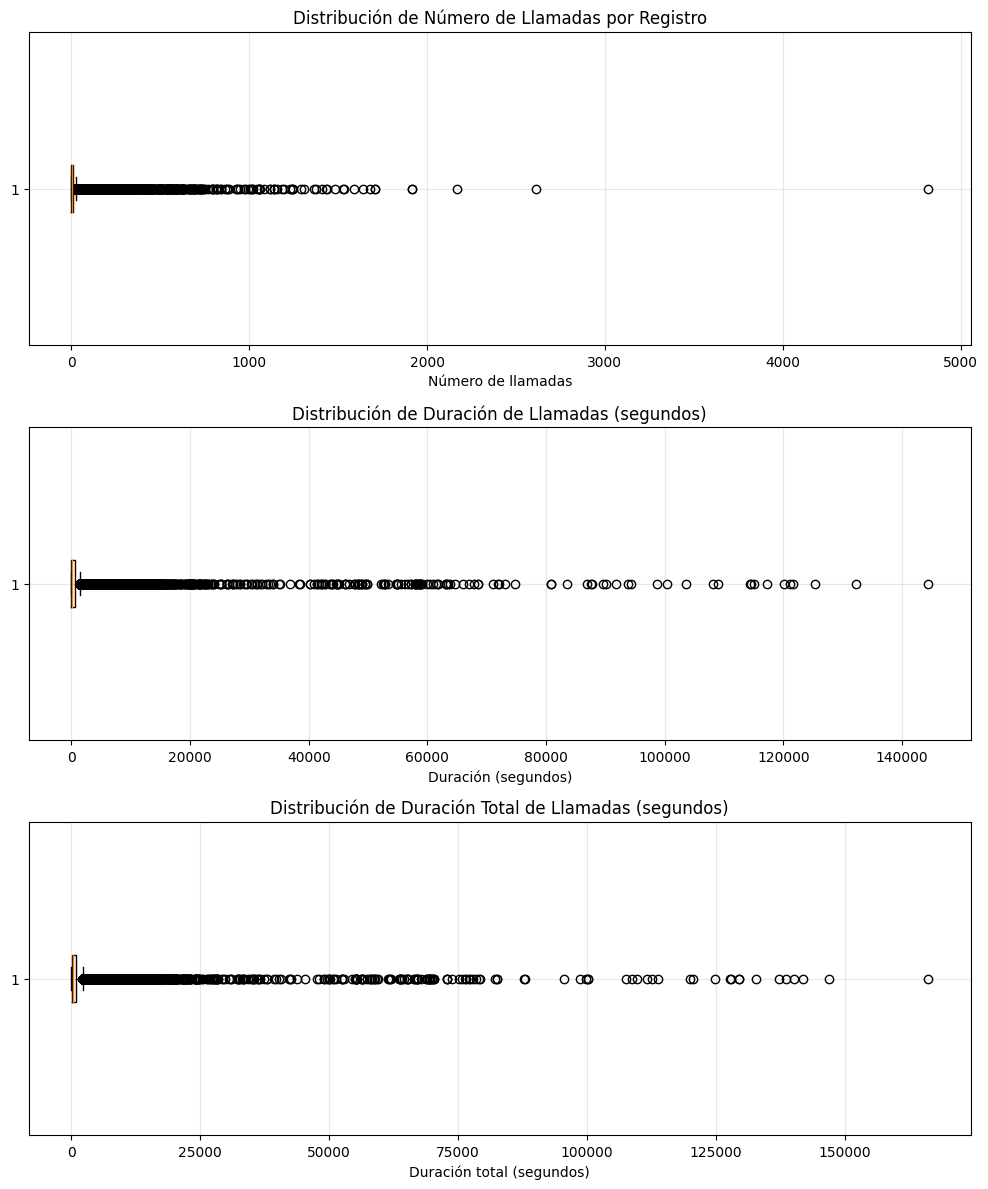

In [119]:
# Boxplots individuales con más detalle
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Calls count
axes[0].boxplot(telecom_data['calls_count'], vert=False)
axes[0].set_title('Distribución de Número de Llamadas por Registro')
axes[0].set_xlabel('Número de llamadas')
axes[0].grid(True, alpha=0.3)

# Call duration
axes[1].boxplot(telecom_data['call_duration'], vert=False)
axes[1].set_title('Distribución de Duración de Llamadas (segundos)')
axes[1].set_xlabel('Duración (segundos)')
axes[1].grid(True, alpha=0.3)

# Total call duration
axes[2].boxplot(telecom_data['total_call_duration'], vert=False)
axes[2].set_title('Distribución de Duración Total de Llamadas (segundos)')
axes[2].set_xlabel('Duración total (segundos)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [120]:
print('=== Resumen estadístico de clientes data ===')
clientes_data.describe()

=== Resumen estadístico de clientes data ===


,user_id
count,732.000000
mean,167431.927596
std,633.810383
min,166373.000000
25%,166900.750000
50%,167432.000000
75%,167973.000000
max,168606.000000


In [121]:
print("=== PLANES TARIFARIOS ===")
print(clientes_data['tariff_plan'].value_counts())

=== PLANES TARIFARIOS ===
C    395
B    261
A     76
Name: tariff_plan, dtype: int64


=== VISUALIZACIÓN DE PLANES TARIFARIOS ===


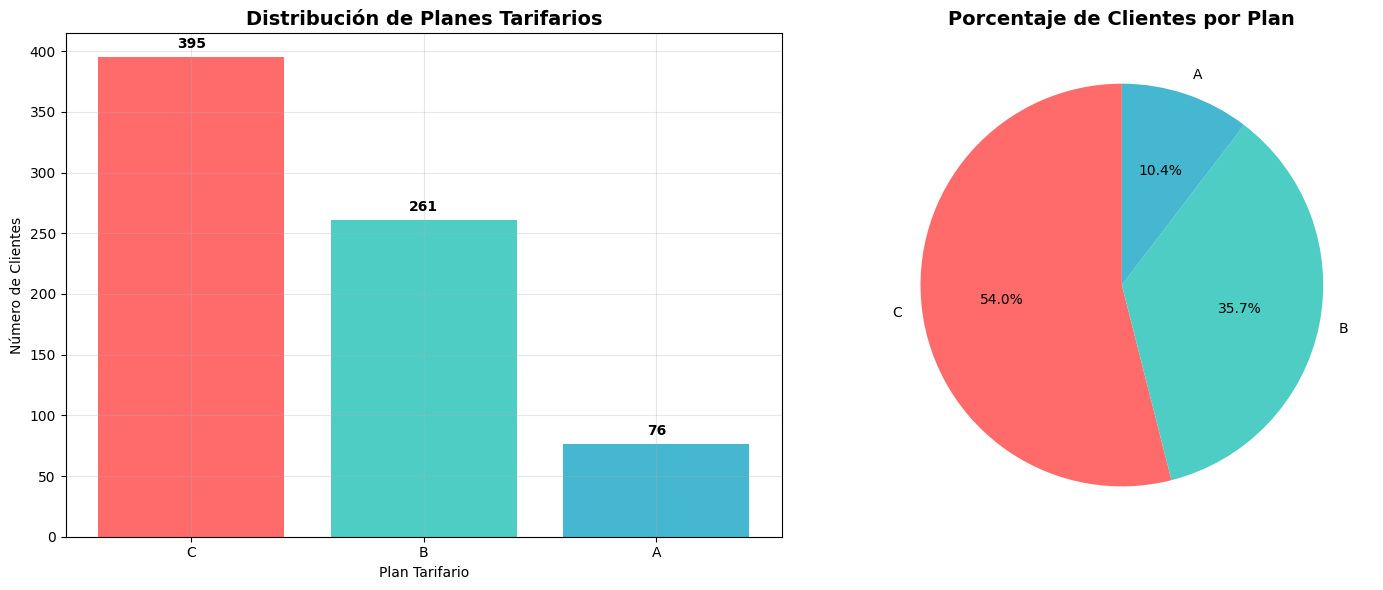

In [122]:
# Gráficas para clientes_data - Planes tarifarios
print("=== VISUALIZACIÓN DE PLANES TARIFARIOS ===")

# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
plan_counts = clientes_data['tariff_plan'].value_counts()
axes[0].bar(plan_counts.index, plan_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Distribución de Planes Tarifarios', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Plan Tarifario')
axes[0].set_ylabel('Número de Clientes')
axes[0].grid(True, alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(plan_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
axes[1].pie(plan_counts.values, labels=plan_counts.index, autopct='%1.1f%%', 
           colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], startangle=90)
axes[1].set_title('Porcentaje de Clientes por Plan', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


=== DISTRIBUCIÓN DE LLAMADAS POR DIRECCIÓN ===
Conteo de llamadas:
out    31917
in     21985
Name: direction, dtype: int64


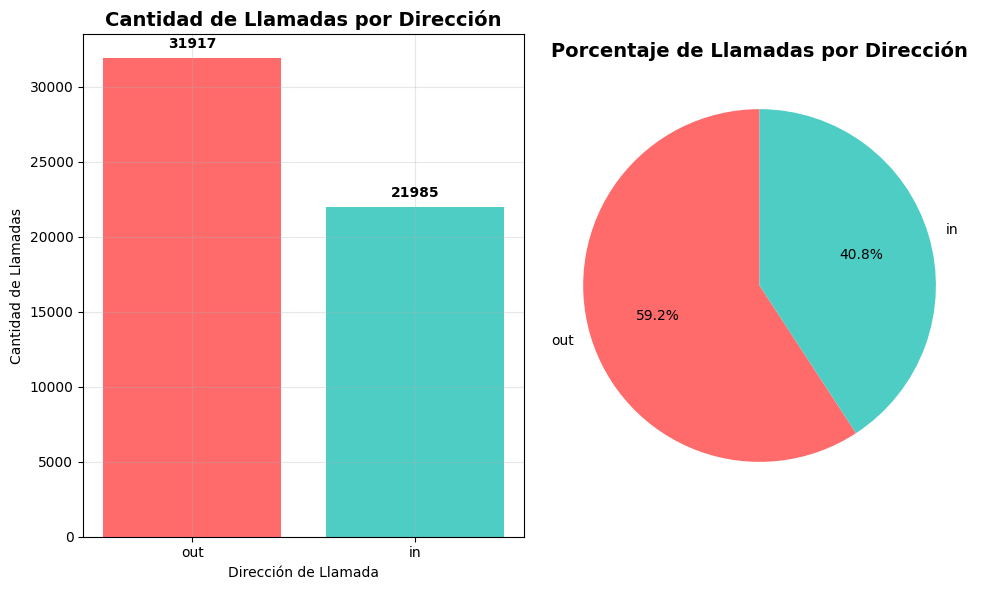

In [123]:
# Gráfico de llamadas IN vs OUT:
print("=== DISTRIBUCIÓN DE LLAMADAS POR DIRECCIÓN ===")

# Contar llamadas por dirección
direction_counts = telecom_data['direction'].value_counts()
print("Conteo de llamadas:")
print(direction_counts)

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Gráfico de barras
plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(direction_counts.index, direction_counts.values, color=colors)
plt.title('Cantidad de Llamadas por Dirección', fontsize=14, fontweight='bold')
plt.xlabel('Dirección de Llamada')
plt.ylabel('Cantidad de Llamadas')
plt.grid(True, alpha=0.3)

# Agregar valores en las barras
for bar, value in zip(bars, direction_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             str(value), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
plt.subplot(1, 2, 2)
plt.pie(direction_counts.values, labels=direction_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Porcentaje de Llamadas por Dirección', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



In [124]:
# Análisis de operadores por dirección de llamadas
print("=== ANÁLISIS DE OPERADORES POR DIRECCIÓN ===")

# Separar llamadas entrantes y salientes
llamadas_in = telecom_data[telecom_data['direction'] == 'in']
llamadas_out = telecom_data[telecom_data['direction'] == 'out']

print(f"Total llamadas entrantes (IN): {len(llamadas_in):,}")
print(f"Total llamadas salientes (OUT): {len(llamadas_out):,}")

=== ANÁLISIS DE OPERADORES POR DIRECCIÓN ===
Total llamadas entrantes (IN): 21,985
Total llamadas salientes (OUT): 31,917


In [125]:
# TABLA 1: Operadores con mayor número de llamadas ENTRANTES (IN)
print("\n=== TOP OPERADORES - LLAMADAS ENTRANTES (IN) ===")

# Contar llamadas entrantes por operador (excluyendo NaN)
operadores_in = llamadas_in['operator_id'].value_counts().head(10)

# Crear DataFrame para mejor visualización
tabla_in = pd.DataFrame({
    'Operator_ID': operadores_in.index,
    'Llamadas_Entrantes': operadores_in.values,
    'Porcentaje': (operadores_in.values / len(llamadas_in) * 100).round(2)
})

print(tabla_in.to_string(index=False))


=== TOP OPERADORES - LLAMADAS ENTRANTES (IN) ===
 Operator_ID  Llamadas_Entrantes  Porcentaje
    901880.0                 121        0.55
    893804.0                 116        0.53
    908960.0                 116        0.53
    885890.0                 103        0.47
    885876.0                 103        0.47
    901884.0                 102        0.46
    908958.0                 100        0.45
    900892.0                  93        0.42
    893402.0                  91        0.41
    913942.0                  90        0.41


In [126]:
# TABLA 2: Operadores con mayor número de llamadas SALIENTES (OUT)
print("\n=== TOP OPERADORES - LLAMADAS SALIENTES (OUT) ===")

# Contar llamadas salientes por operador (excluyendo NaN)
operadores_out = llamadas_out['operator_id'].value_counts().head(10)

# Crear DataFrame para mejor visualización
tabla_out = pd.DataFrame({
    'Operator_ID': operadores_out.index,
    'Llamadas_Salientes': operadores_out.values,
    'Porcentaje': (operadores_out.values / len(llamadas_out) * 100).round(2)
})

print(tabla_out.to_string(index=False))


=== TOP OPERADORES - LLAMADAS SALIENTES (OUT) ===
 Operator_ID  Llamadas_Salientes  Porcentaje
    901884.0                 246        0.77
    885876.0                 216        0.68
    901880.0                 216        0.68
    887276.0                 215        0.67
    891414.0                 212        0.66
    891410.0                 211        0.66
    905538.0                 209        0.65
    893804.0                 209        0.65
    879898.0                 187        0.59
    905566.0                 186        0.58


In [127]:
# Tiempo de espera variable nueva
print('=== Tiempo de espera de las llamadas ===')
print()
tiempo_de_espera = telecom_data['total_call_duration']- (telecom_data['call_duration'])
print(tiempo_de_espera.head(20))
print()
print('=== Tiempo promedio de espera de las llamdas ===')
tiempo_de_espera.mean()

=== Tiempo de espera de las llamadas ===

0      4
1      5
2      1
3      8
4     25
5     26
6     50
7     35
8     50
9     62
10    29
11    70
12     5
13    19
14    15
15     7
16     8
17    24
18    17
19    10
dtype: int64

=== Tiempo promedio de espera de las llamdas ===


290.44887017179326

In [128]:
#promedio de las llamadas

# === CÁLCULO DE PROMEDIOS DE LLAMADAS ===
print("=== ANÁLISIS DE PROMEDIOS DE LLAMADAS ===")

# 1. Promedio de llamadas por usuario
llamadas_por_usuario = telecom_data.groupby('user_id').size()
promedio_llamadas_usuario = llamadas_por_usuario.mean()

print(f"Promedio de llamadas por usuario: {promedio_llamadas_usuario:.2f}")
print(f"Mediana de llamadas por usuario: {llamadas_por_usuario.median():.2f}")
print(f"Usuario con más llamadas: {llamadas_por_usuario.max()} llamadas")
print(f"Usuario con menos llamadas: {llamadas_por_usuario.min()} llamadas")

=== ANÁLISIS DE PROMEDIOS DE LLAMADAS ===
Promedio de llamadas por usuario: 175.58
Mediana de llamadas por usuario: 67.00
Usuario con más llamadas: 2580 llamadas
Usuario con menos llamadas: 1 llamadas


In [129]:
# Promedio de duración de llamadas
print("\n=== PROMEDIOS DE DURACIÓN ===")

# Promedio de duración por llamada (solo llamadas contestadas)
llamadas_contestadas = telecom_data[telecom_data['call_duration'] > 0]
promedio_duracion = llamadas_contestadas['call_duration'].mean()

print(f"Promedio de duración de llamadas contestadas: {promedio_duracion:.2f} segundos ({promedio_duracion/60:.2f} minutos)")
print(f"Promedio de duración total (incluyendo espera): {telecom_data['total_call_duration'].mean():.2f} segundos")
print(f"Promedio de tiempo de espera: {tiempo_de_espera.mean():.2f} segundos")


=== PROMEDIOS DE DURACIÓN ===
Promedio de duración de llamadas contestadas: 1524.72 segundos (25.41 minutos)
Promedio de duración total (incluyendo espera): 1157.13 segundos
Promedio de tiempo de espera: 290.45 segundos


## Criterios de ineficiencia 

In [130]:
#Crear variable para las llamadas entrantes perdidas
llamadas_in_lose = telecom_data.query('is_missed_call==1 and direction=="in"').groupby('user_id')['calls_count'].sum().reset_index()
llamadas_in_lose = llamadas_in_lose.query('calls_count<=500')

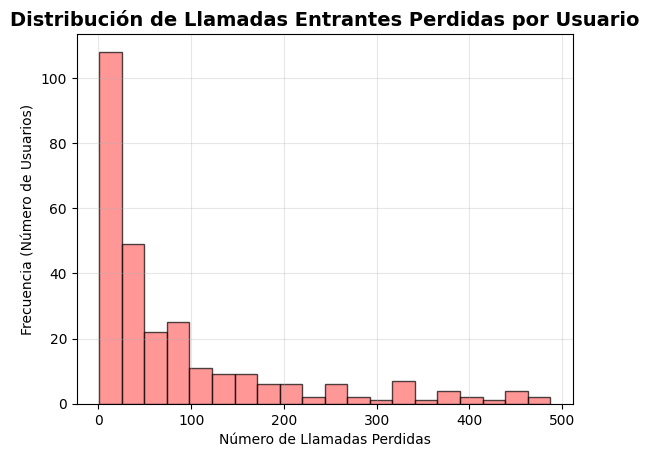

In [131]:
#1 .Determinar el rango de ineficiencia de las llamadas entrantes perdidas.

llamadas_in_lose['calls_count'].plot(kind='hist', bins=20, color='#FF6B6B', alpha=0.7, edgecolor='black')
plt.title('Distribución de Llamadas Entrantes Perdidas por Usuario', fontsize=14, fontweight='bold')
plt.xlabel('Número de Llamadas Perdidas')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(True, alpha=0.3)


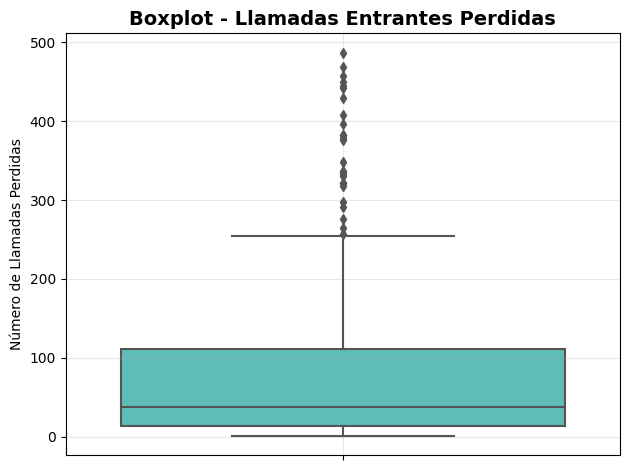

In [132]:

sns.boxplot(data=llamadas_in_lose, y='calls_count', color='#4ECDC4')
plt.title('Boxplot - Llamadas Entrantes Perdidas', fontsize=14, fontweight='bold')
plt.ylabel('Número de Llamadas Perdidas')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [133]:
# Estadísticas descriptivas para evaluar el umbral
print("=== ANÁLISIS DE LLAMADAS ENTRANTES PERDIDAS ===")
print(f"Total de usuarios analizados: {len(llamadas_in_lose)}")
print(f"Promedio de llamadas perdidas: {llamadas_in_lose['calls_count'].mean():.2f}")
print(f"Mediana de llamadas perdidas: {llamadas_in_lose['calls_count'].median():.2f}")
print(f"Desviación estándar: {llamadas_in_lose['calls_count'].std():.2f}")

print("\n=== PERCENTILES ===")
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    valor = llamadas_in_lose['calls_count'].quantile(p/100)
    print(f"Percentil {p}: {valor:.0f} llamadas perdidas")

=== ANÁLISIS DE LLAMADAS ENTRANTES PERDIDAS ===
Total de usuarios analizados: 277
Promedio de llamadas perdidas: 85.70
Mediana de llamadas perdidas: 38.00
Desviación estándar: 109.20

=== PERCENTILES ===
Percentil 25: 14 llamadas perdidas
Percentil 50: 38 llamadas perdidas
Percentil 75: 111 llamadas perdidas
Percentil 90: 248 llamadas perdidas
Percentil 95: 339 llamadas perdidas


Teniendo en cuenta los gráficos y el  promedio de llamadas entrantes perdidas,daré un umbral de 200 llamadas entrantes perdidas mayor a el usuario será detectado como ineficiente.

In [134]:

# Análisis del umbral propuesto de 200 llamadas
umbral_propuesto = 200

usuarios_ineficientes = llamadas_in_lose[llamadas_in_lose['calls_count'] > umbral_propuesto]
usuarios_eficientes = llamadas_in_lose[llamadas_in_lose['calls_count'] <= umbral_propuesto]

print(f"\n=== EVALUACIÓN DEL UMBRAL DE {umbral_propuesto} LLAMADAS ===")
print(f"Usuarios con MÁS de {umbral_propuesto} llamadas perdidas (INEFICIENTES): {len(usuarios_ineficientes)} ({len(usuarios_ineficientes)/len(llamadas_in_lose)*100:.1f}%)")
print(f"Usuarios con {umbral_propuesto} o MENOS llamadas perdidas (EFICIENTES): {len(usuarios_eficientes)} ({len(usuarios_eficientes)/len(llamadas_in_lose)*100:.1f}%)")

print(f"\nPromedio de llamadas perdidas en usuarios INEFICIENTES: {usuarios_ineficientes['calls_count'].mean():.2f}")
print(f"Promedio de llamadas perdidas en usuarios EFICIENTES: {usuarios_eficientes['calls_count'].mean():.2f}")




=== EVALUACIÓN DEL UMBRAL DE 200 LLAMADAS ===
Usuarios con MÁS de 200 llamadas perdidas (INEFICIENTES): 38 (13.7%)
Usuarios con 200 o MENOS llamadas perdidas (EFICIENTES): 239 (86.3%)

Promedio de llamadas perdidas en usuarios INEFICIENTES: 322.79
Promedio de llamadas perdidas en usuarios EFICIENTES: 48.01


Con el primer filtro, podemos identificar alrededor del 13,7% de los operadores ineficientes.

In [135]:
# 2.Encontrar umbral de ineficiencia para tiempo de espera prolongado para llamadas entrantes
telecom_data['tiempo_de_espera'] = telecom_data['total_call_duration'] - telecom_data['call_duration']

In [136]:
# Filtrar llamadas entrantes y calcular tiempo de espera promedio por usuario

llamadas_in_tiempo_espera = telecom_data[telecom_data['direction'] == 'in'].groupby('user_id').agg({
    'tiempo_de_espera': ['mean', 'sum', 'count']
}).round(2)


# Aplanar las columnas
llamadas_in_tiempo_espera.columns = ['tiempo_espera_promedio', 'tiempo_espera_total', 'total_llamadas_in']
llamadas_in_tiempo_espera = llamadas_in_tiempo_espera.reset_index()

print("=== ANÁLISIS DE TIEMPO DE ESPERA EN LLAMADAS ENTRANTES ===")
print(f"Total de usuarios con llamadas entrantes: {len(llamadas_in_tiempo_espera)}")
print(llamadas_in_tiempo_espera.head())

=== ANÁLISIS DE TIEMPO DE ESPERA EN LLAMADAS ENTRANTES ===
Total de usuarios con llamadas entrantes: 307
   user_id  tiempo_espera_promedio  tiempo_espera_total  total_llamadas_in
0   166377                   18.57                 2228                120
1   166391                   34.84                  662                 19
2   166392                   38.76                 4147                107
3   166399                   25.52                  587                 23
4   166405                  321.22               124632                388


In [137]:
# Estadísticas descriptivas del tiempo de espera promedio
print("=== ESTADÍSTICAS DE TIEMPO DE ESPERA PROMEDIO ===")
print(f"Promedio general: {llamadas_in_tiempo_espera['tiempo_espera_promedio'].mean():.2f} segundos")
print(f"Mediana: {llamadas_in_tiempo_espera['tiempo_espera_promedio'].median():.2f} segundos")
print(f"Desviación estándar: {llamadas_in_tiempo_espera['tiempo_espera_promedio'].std():.2f} segundos")

print("\n=== PERCENTILES DE TIEMPO DE ESPERA PROMEDIO ===")
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    valor = llamadas_in_tiempo_espera['tiempo_espera_promedio'].quantile(p/100)
    print(f"Percentil {p}: {valor:.2f} segundos")

=== ESTADÍSTICAS DE TIEMPO DE ESPERA PROMEDIO ===
Promedio general: 69.96 segundos
Mediana: 32.00 segundos
Desviación estándar: 140.63 segundos

=== PERCENTILES DE TIEMPO DE ESPERA PROMEDIO ===
Percentil 25: 17.04 segundos
Percentil 50: 32.00 segundos
Percentil 75: 56.70 segundos
Percentil 90: 147.13 segundos
Percentil 95: 275.55 segundos


Text(0, 0.5, 'Frecuencia (Número de Usuarios)')

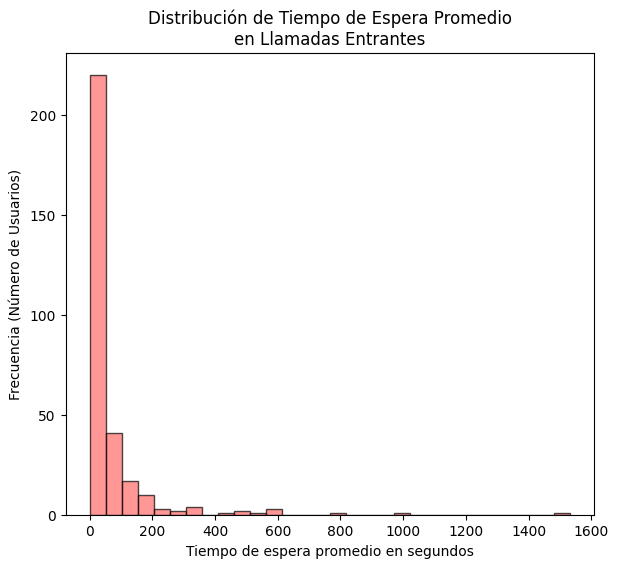

In [138]:
# Gráficas para tiempo de espera
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
llamadas_in_tiempo_espera['tiempo_espera_promedio'].plot(kind='hist', bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
plt.title('Distribución de Tiempo de Espera Promedio\nen Llamadas Entrantes')
plt.xlabel('Tiempo de espera promedio en segundos')
plt.ylabel('Frecuencia (Número de Usuarios)')



Se define un nivel de ineficiencia para los 3 minutos o sea 180 segundos esto teniendo encuenta que el call center es de servicio al cliente y un timepo prudente de espera es en teoria normal.ademas donde graficamente aun vemos datos visibles y/o significativos para el nalisi alredor de los 200s.

In [139]:
# Análisis del umbral propuesto de 180 segundos para tiempo de espera
umbral_tiempo_espera = 180
usuarios_tiempo_ineficiente = llamadas_in_tiempo_espera[llamadas_in_tiempo_espera['tiempo_espera_promedio'] > umbral_tiempo_espera]
usuarios_tiempo_eficiente = llamadas_in_tiempo_espera[llamadas_in_tiempo_espera['tiempo_espera_promedio'] <= umbral_tiempo_espera]

print(f"=== EVALUACIÓN DEL UMBRAL DE {umbral_tiempo_espera} SEGUNDOS ===")
print(f"Usuarios con MÁS de {umbral_tiempo_espera}s de espera promedio (INEFICIENTES): {len(usuarios_tiempo_ineficiente)} ({len(usuarios_tiempo_ineficiente)/len(llamadas_in_tiempo_espera)*100:.1f}%)")
print(f"Usuarios con {umbral_tiempo_espera}s o MENOS de espera promedio (EFICIENTES): {len(usuarios_tiempo_eficiente)} ({len(usuarios_tiempo_eficiente)/len(llamadas_in_tiempo_espera)*100:.1f}%)")

=== EVALUACIÓN DEL UMBRAL DE 180 SEGUNDOS ===
Usuarios con MÁS de 180s de espera promedio (INEFICIENTES): 22 (7.2%)
Usuarios con 180s o MENOS de espera promedio (EFICIENTES): 285 (92.8%)


In [140]:
# 3.criterio de ineficiencia n.º reducido de llamadas salientes
# Filtrar llamadas salientes y agrupar por usuario
llamadas_out_usuario = telecom_data[telecom_data['direction'] == 'out'].groupby('user_id').agg({
    'calls_count': 'sum',
    'call_duration': ['sum', 'mean', 'count']
}).round(2)

# Aplanar las columnas
llamadas_out_usuario.columns = ['total_llamadas_out', 'duracion_total_out', 'duracion_promedio_out', 'registros_out']
llamadas_out_usuario = llamadas_out_usuario.reset_index()

print("=== ANÁLISIS DE LLAMADAS SALIENTES POR USUARIO ===")
print(f"Total de usuarios con llamadas salientes: {len(llamadas_out_usuario)}")
print(llamadas_out_usuario.head())

=== ANÁLISIS DE LLAMADAS SALIENTES POR USUARIO ===
Total de usuarios con llamadas salientes: 222
   user_id  total_llamadas_out  duracion_total_out  duracion_promedio_out  \
0   166377                5528              351246                 778.82   
1   166391                   1                   0                   0.00   
2   166405               10700              845334                1292.56   
3   166406                8976              353285                1154.53   
4   166407                 928               42822                 109.52   

   registros_out  
0            451  
1              1  
2            654  
3            306  
4            391  


In [141]:
# Estadísticas descriptivas de llamadas salientes
print("=== ESTADÍSTICAS DE LLAMADAS SALIENTES ===")
print(f"Promedio de llamadas salientes por usuario: {llamadas_out_usuario['total_llamadas_out'].mean():.2f}")
print(f"Mediana de llamadas salientes: {llamadas_out_usuario['total_llamadas_out'].median():.2f}")
print(f"Desviación estándar: {llamadas_out_usuario['total_llamadas_out'].std():.2f}")

print("\n=== PERCENTILES DE LLAMADAS SALIENTES ===")
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    valor = llamadas_out_usuario['total_llamadas_out'].quantile(p/100)
    print(f"Percentil {p}: {valor:.0f} llamadas salientes")

=== ESTADÍSTICAS DE LLAMADAS SALIENTES ===
Promedio de llamadas salientes por usuario: 3017.53
Mediana de llamadas salientes: 266.50
Desviación estándar: 12743.38

=== PERCENTILES DE LLAMADAS SALIENTES ===
Percentil 10: 6 llamadas salientes
Percentil 25: 35 llamadas salientes
Percentil 50: 266 llamadas salientes
Percentil 75: 1436 llamadas salientes
Percentil 90: 5144 llamadas salientes


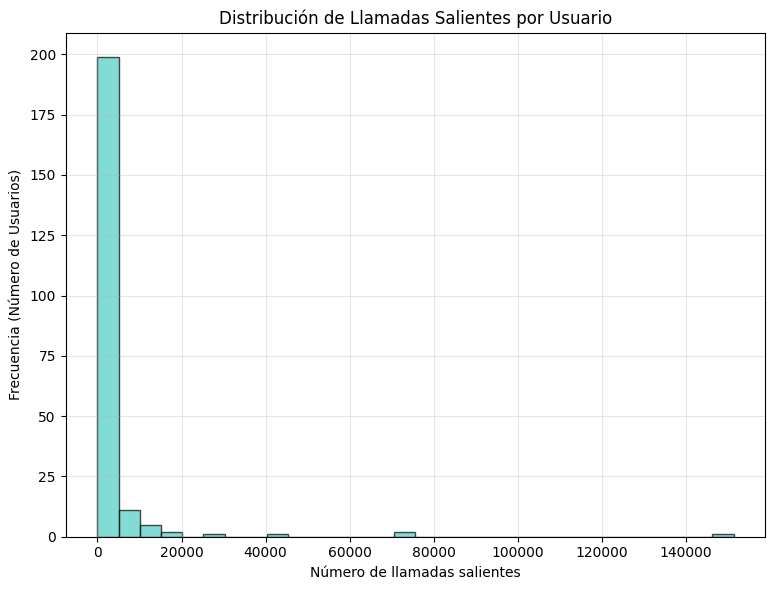

In [142]:

# Visualización de la distribución
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
llamadas_out_usuario['total_llamadas_out'].plot(kind='hist', bins=30, color='#4ECDC4', alpha=0.7, edgecolor='black')
plt.title('Distribución de Llamadas Salientes por Usuario')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Como en los otros dos criterios, podemos encontrar una distribución con una desviación estándar  muy alta, lo que indica que hay datos muy dispersos, lo que dificulta un poco el umbral en este caso. Así que voy a filtrar el dataFrame en 2000, donde se encuentra la mayor concentración de los datos, más adecuada a la media.

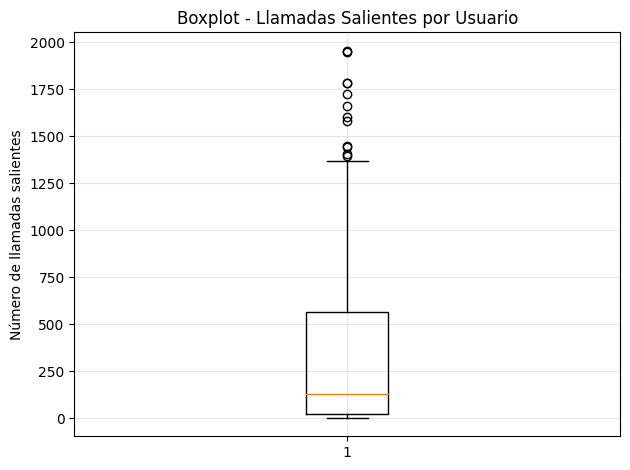

In [143]:
# un boxplot de las llamadas salientes
llamadas_out_usuar_2000 = llamadas_out_usuario[llamadas_out_usuario['total_llamadas_out']<2000]  
plt.boxplot(llamadas_out_usuar_2000['total_llamadas_out'], vert=True)
plt.title('Boxplot - Llamadas Salientes por Usuario')
plt.ylabel('Número de llamadas salientes')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Bajo este criterio y esta gráfica decidí que los operadores con menos de 2000 llamadas salientes serán ineficientes.

In [144]:
# Análisis del umbral de 2000 llamadas salientes
print("=== ANÁLISIS DEL UMBRAL: < 2000 LLAMADAS SALIENTES ===")

# Contar usuarios por debajo y por encima del umbral
usuarios_ineficientes_out = llamadas_out_usuario[llamadas_out_usuario['total_llamadas_out'] < 2000]
usuarios_eficientes_out = llamadas_out_usuario[llamadas_out_usuario['total_llamadas_out'] >= 2000]

total_usuarios = len(llamadas_out_usuario)
ineficientes_count = len(usuarios_ineficientes_out)
eficientes_count = len(usuarios_eficientes_out)

print(f"Total de usuarios analizados: {total_usuarios}")
print(f"Usuarios INEFICIENTES (< 2000 llamadas salientes): {ineficientes_count} ({ineficientes_count/total_usuarios*100:.1f}%)")
print(f"Usuarios EFICIENTES (≥ 2000 llamadas salientes): {eficientes_count} ({eficientes_count/total_usuarios*100:.1f}%)")

=== ANÁLISIS DEL UMBRAL: < 2000 LLAMADAS SALIENTES ===
Total de usuarios analizados: 222
Usuarios INEFICIENTES (< 2000 llamadas salientes): 176 (79.3%)
Usuarios EFICIENTES (≥ 2000 llamadas salientes): 46 (20.7%)


El porcentaje de operadores insuficientes para este criterio es bastante alto,se recomienda entrar a revisar esta área específica en los operadores, tal vez hay variables  que generan este porcentaje tan alto de ineficiencia.

# Planteamiento de la hipotesis


H0  = Todos los operadores tienen la misma eficiencia en la duración promedio de sus llamadas entrantes (in).

H1  = Existen diferencias significativas en la duración promedio de llamadas entrantes (in)


In [145]:
# Preparación específica para la hipótesis de operadores
print("=== DATOS PARA HIPÓTESIS: DURACIÓN POR OPERADOR ===")

# Filtrar llamadas entrantes contestadas con operator_id válido
llamadas_in_operadores = telecom_data[
    (telecom_data['direction'] == 'in') & 
    (telecom_data['call_duration'] > 0) &
    (telecom_data['operator_id'].notna())
]

print(f"Llamadas entrantes contestadas con operador: {len(llamadas_in_operadores):,}")
print(f"Operadores únicos: {llamadas_in_operadores['operator_id'].nunique()}")

=== DATOS PARA HIPÓTESIS: DURACIÓN POR OPERADOR ===
Llamadas entrantes contestadas con operador: 13,570
Operadores únicos: 754


In [146]:
# Calcular duración promedio por operador
duracion_por_operador = llamadas_in_operadores.groupby('operator_id').agg({
    'call_duration': ['mean', 'count', 'std']
}).round(2)

duracion_por_operador.columns = ['duracion_promedio', 'num_llamadas', 'desviacion_std']
duracion_por_operador = duracion_por_operador.reset_index()

# Filtrar operadores con al menos 10 llamadas para análisis confiable
duracion_por_operador_filtrado = duracion_por_operador[duracion_por_operador['num_llamadas'] >= 10]

print(f"Operadores con al menos 10 llamadas: {len(duracion_por_operador_filtrado)}")
print("\n=== PRIMEROS 10 OPERADORES ===")
print(duracion_por_operador_filtrado.head(10))

Operadores con al menos 10 llamadas: 382

=== PRIMEROS 10 OPERADORES ===
    operator_id  duracion_promedio  num_llamadas  desviacion_std
0      879896.0             246.17            23          341.58
1      879898.0             110.23            64           99.44
4      880026.0              85.89            19          122.83
5      880028.0             125.67            45          108.14
8      882680.0             146.47            43          201.44
9      882684.0            2873.65            48         2042.35
10     882686.0            2289.19            68         1986.66
12     882690.0             680.86            22          573.24
14     883942.0             231.02            42          196.86
16     884408.0             140.00            15          135.30


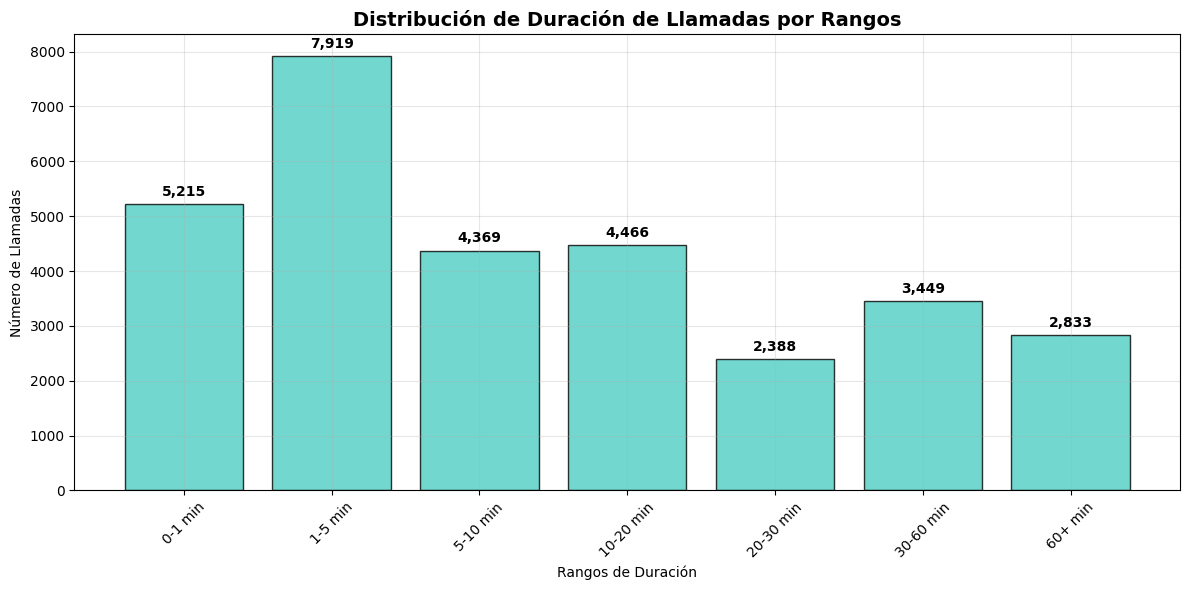

=== RESUMEN POR RANGOS ===
0-1 min: 5,215 llamadas (17.0%)
1-5 min: 7,919 llamadas (25.8%)
5-10 min: 4,369 llamadas (14.3%)
10-20 min: 4,466 llamadas (14.6%)
20-30 min: 2,388 llamadas (7.8%)
30-60 min: 3,449 llamadas (11.3%)
60+ min: 2,833 llamadas (9.2%)


In [147]:
# Crear rangos de duración para mejor visualización
import numpy as np

# Filtrar solo llamadas contestadas
llamadas_contestadas = telecom_data[telecom_data['call_duration'] > 0]

# Crear rangos de duración en minutos
bins = [0, 1, 5, 10, 20, 30, 60, np.inf]
labels = ['0-1 min', '1-5 min', '5-10 min', '10-20 min', '20-30 min', '30-60 min', '60+ min']

# Convertir a minutos y categorizar
duracion_minutos = llamadas_contestadas['call_duration'] / 60
rangos_duracion = pd.cut(duracion_minutos, bins=bins, labels=labels, right=False)

# Contar frecuencias
conteo_rangos = rangos_duracion.value_counts().sort_index()

# Crear gráfico de barras
plt.figure(figsize=(12, 6))
bars = plt.bar(conteo_rangos.index, conteo_rangos.values, color='#4ECDC4', alpha=0.8, edgecolor='black')
plt.title('Distribución de Duración de Llamadas por Rangos', fontsize=14, fontweight='bold')
plt.xlabel('Rangos de Duración')
plt.ylabel('Número de Llamadas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Agregar valores en las barras
for bar, value in zip(bars, conteo_rangos.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{value:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("=== RESUMEN POR RANGOS ===")
for rango, cantidad in conteo_rangos.items():
    porcentaje = (cantidad / len(llamadas_contestadas)) * 100
    print(f"{rango}: {cantidad:,} llamadas ({porcentaje:.1f}%)")

Voy a dividir el grupo de los eficientes e ineficientes en percentiles para minimizar un  poco la dispersión, escogí hacer la prueba MANN-WHITNEY U ya que trabaja bien con altas dispersiones.

In [148]:
# Crear grupos de operadores basados en duración promedio
print("=== CREACIÓN DE GRUPOS DE OPERADORES ===")

# Calcular percentiles para definir grupos
percentil_25 = duracion_por_operador_filtrado['duracion_promedio'].quantile(0.25)
percentil_75 = duracion_por_operador_filtrado['duracion_promedio'].quantile(0.75)

print(f"Percentil 25: {percentil_25:.2f} segundos")
print(f"Percentil 75: {percentil_75:.2f} segundos")

# Definir grupos
grupo_eficiente = duracion_por_operador_filtrado[
    duracion_por_operador_filtrado['duracion_promedio'] <= percentil_25
]

grupo_ineficiente = duracion_por_operador_filtrado[
    duracion_por_operador_filtrado['duracion_promedio'] >= percentil_75
]

=== CREACIÓN DE GRUPOS DE OPERADORES ===
Percentil 25: 163.64 segundos
Percentil 75: 718.27 segundos


In [149]:
# Extraer las duraciones individuales de cada grupo para la prueba
print("=== PREPARACIÓN PARA MANN-WHITNEY U ===")

# Obtener todas las llamadas de operadores eficientes
llamadas_grupo_eficiente = llamadas_in_operadores[
    llamadas_in_operadores['operator_id'].isin(grupo_eficiente['operator_id'])
]['call_duration']

# Obtener todas las llamadas de operadores ineficientes  
llamadas_grupo_ineficiente = llamadas_in_operadores[
    llamadas_in_operadores['operator_id'].isin(grupo_ineficiente['operator_id'])
]['call_duration']

print(f"Llamadas del grupo eficiente: {len(llamadas_grupo_eficiente):,}")
print(f"Llamadas del grupo ineficiente: {len(llamadas_grupo_ineficiente):,}")

=== PREPARACIÓN PARA MANN-WHITNEY U ===
Llamadas del grupo eficiente: 1,963
Llamadas del grupo ineficiente: 4,382


In [150]:
from scipy import stats
import numpy as np

print("=== PRUEBA MANN-WHITNEY U ===")

# Realizar la prueba Mann-Whitney U
statistic, p_value = stats.mannwhitneyu(
    llamadas_grupo_eficiente, 
    llamadas_grupo_ineficiente, 
    alternative='two-sided'  # Prueba de dos colas
)

print(f"Estadístico U: {statistic:,.0f}")
print(f"P-value: {p_value:.10f}")

# Nivel de significancia
alpha = 0.05
print(f"Nivel de significancia (α): {alpha}")

# Interpretación del resultado
print("\n=== INTERPRETACIÓN ===")
if p_value < alpha:
    print("✅ RECHAZAMOS H₀: Existe diferencia significativa entre grupos")
    print("   Los operadores eficientes e ineficientes tienen duraciones diferentes")
else:
    print("❌ NO RECHAZAMOS H₀: No existe diferencia significativa entre grupos")
    print("   Los operadores eficientes e ineficientes tienen duraciones similares")

print(f"\nConclusión: Con un p-value de {p_value:.10f}, {'SÍ' if p_value < alpha else 'NO'} hay evidencia estadística suficiente")

=== PRUEBA MANN-WHITNEY U ===
Estadístico U: 857,103
P-value: 0.0000000000
Nivel de significancia (α): 0.05

=== INTERPRETACIÓN ===
✅ RECHAZAMOS H₀: Existe diferencia significativa entre grupos
   Los operadores eficientes e ineficientes tienen duraciones diferentes

Conclusión: Con un p-value de 0.0000000000, SÍ hay evidencia estadística suficiente


Este resultado no es sorprendente ya que las conclusiones que se arrojaron de los criterios que se hicieron anteriormente, son consistentes con este resultado ya tanto por la dispersion de los datos, como el resultado de los umbrales, por tanto hay suficiente evidencia estadística para rechazar la hipótesis.


In [151]:
# Extraer información de fecha
telecom_data['dia'] = telecom_data['date'].dt.date
telecom_data['dia_semana'] = telecom_data['date'].dt.day_name()
telecom_data['mes'] = telecom_data['date'].dt.month

In [152]:
# Duración en minutos para mejor visualización
telecom_data['duracion_minutos'] = telecom_data['call_duration'] / 60
telecom_data['tiempo_espera_minutos'] = telecom_data['tiempo_de_espera'] / 60

In [153]:
telecom_data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tiempo_de_espera,dia,dia_semana,mes,duracion_minutos,tiempo_espera_minutos
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,4,2019-08-04,Sunday,8,0.000000,0.066667
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,2019-08-05,Monday,8,0.000000,0.083333
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,2019-08-05,Monday,8,0.000000,0.016667
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,2019-08-05,Monday,8,0.166667,0.133333
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25,2019-08-05,Monday,8,0.000000,0.416667


## 🔗 Link de interes:
📊  dashboard:  https://public.tableau.com/views/proyectofinal15/Dashboard1?:language=es-ES&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link
📋  informe final: https://drive.google.com/drive/folders/1DQdnel3e7v4R7n2bGU1fHyo3B_DtDmh1?usp=drive_link

In [155]:
telecom_data.to_csv('telecom_data_clean.csv',index=False)